In [1]:
import random

def generate_graph_file(filename, num_nodes, density=0.3, max_weight=20):
    """
    Genera un archivo de grafo aleatorio.
    density: probabilidad de que exista una arista entre dos nodos.
    """
    edges = []
    # Asegurarnos de que el grafo sea conexo (simple path lineal primero)
    for i in range(1, num_nodes):
        weight = random.randint(1, max_weight)
        edges.append(f"{i} {i+1} {weight}")
    
    # Añadir aristas aleatorias adicionales
    for i in range(1, num_nodes + 1):
        for j in range(i + 1, num_nodes + 1):
            if random.random() < density and j != i+1: # Evitar duplicar el camino lineal base
                weight = random.randint(1, max_weight)
                edges.append(f"{i} {j} {weight}")

    with open(filename, 'w') as f:
        f.write(f"{num_nodes}\n")
        for edge in edges:
            f.write(f"{edge}\n")
    print(f"Generado {filename} con {num_nodes} nodos y {len(edges)} aristas.")

# Generar 3 ejemplos
generate_graph_file('graph_small.txt', num_nodes=5, density=0.4)
generate_graph_file('graph_medium.txt', num_nodes=10, density=0.3)
generate_graph_file('graph_large.txt', num_nodes=20, density=0.2)

Generado graph_small.txt con 5 nodos y 6 aristas.
Generado graph_medium.txt con 10 nodos y 28 aristas.
Generado graph_large.txt con 20 nodos y 53 aristas.


In [2]:
import numpy as np
import pygad
import pandas as pd

# --- 1. FUNCIÓN PARA LEER EL GRAFO ---
def load_graph(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    num_nodes = int(lines[0].strip())
    adj_matrix = np.full((num_nodes + 1, num_nodes + 1), np.inf) # Infinito significa sin conexión
    
    for line in lines[1:]:
        parts = list(map(int, line.strip().split()))
        if len(parts) == 3:
            u, v, w = parts
            # Asumimos grafo no dirigido (bidireccional)
            adj_matrix[u][v] = w
            
    return num_nodes, adj_matrix

# --- 2. CONFIGURACIÓN DEL PROBLEMA ---
filename = 'graph_medium.txt' # CAMBIA ESTO para probar otros archivos
start_node = 1
end_node = 10  # Asegúrate de que este nodo exista en el grafo que elijas (ej. 5 para small, 10 para medium)

num_nodes, adj_matrix = load_graph(filename)

print(f"Buscando camino de {start_node} a {end_node} en {filename}")

# --- 3. DEFINIR LA FITNESS FUNCTION ---
def fitness_func(ga_instance, solution, solution_idx):
    """
    El cromosoma será una lista de nodos de longitud fija (num_nodes).
    Interpretación: El camino es la secuencia de nodos en el cromosoma.
    Cortamos el camino en cuanto llegamos al 'end_node'.
    """
    total_dist = 0
    current_node = start_node
    
    # Si el gen 0 no es el nodo de inicio, penalizamos (opcional, o forzamos inicio)
    # Estrategia: Ignoramos el cromosoma y asumimos que siempre empezamos en start_node.
    # El cromosoma decide el SIGUIENTE paso.
    
    path_found = False
    nodes_visited = [start_node]
    
    for next_node_idx in solution:
        next_node = int(next_node_idx)
        
        if next_node == current_node:
            continue # Saltamos si es el mismo nodo
        
        if next_node in nodes_visited:
             continue # Evitamos ciclos
            
        dist = adj_matrix[current_node][next_node]
        
        if dist == np.inf:
            # Penalización suave: si intenta cruzar una pared, sumamos mucho costo
            # pero permitimos que el algoritmo aprenda.
            total_dist += 1000 
        else:
            total_dist += dist
            current_node = next_node
            nodes_visited.append(current_node)
        
        if current_node == end_node:
            path_found = True
            break
            
    # Si no llegó al final, penalización masiva
    if not path_found:
        total_dist += 100000

    # PyGAD maximiza fitness, así que retornamos 1/distancia
    if total_dist == 0: return 99999 # Evitar división por cero
    return 1.0 / total_dist

# --- 4. CONFIGURACIÓN DEL GA (EXPERIMENTACIÓN) ---
# Aquí es donde debes "Experimentar con diferentes parámetros" como pide el enunciado.

fitness_function = fitness_func

# Gene space: Los genes pueden ser cualquier nodo del 1 al num_nodes
gene_space = list(range(1, num_nodes + 1))

ga_instance = pygad.GA(
    num_generations=100,      # Prueba subir a 200 o 500 para grafos grandes
    num_parents_mating=10,
    fitness_func=fitness_function,
    sol_per_pop=50,           # Población: prueba 20, 50, 100
    num_genes=num_nodes,      # Longitud máxima del camino
    gene_type=int,
    parent_selection_type="rws", # Roulette Wheel Selection. Prueba "sus", "rank"
    keep_parents=2,
    crossover_type="single_point", # Prueba "two_points", "uniform"
    mutation_type="random",   # Prueba "swap", "inversion"
    mutation_percent_genes=20, # Probabilidad de mutación. Prueba 10, 30
    gene_space=gene_space,
    allow_duplicate_genes=False # Importante: No queremos visitar el mismo nodo dos veces en un camino
)

# --- 5. EJECUCIÓN ---
ga_instance.run()

# --- 6. RESULTADOS ---
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Mejor Fitness: {solution_fitness}")

# Decodificar el camino para mostrarlo
decoded_path = [start_node]
curr = start_node
dist_real = 0
valid = True

for node in solution:
    node = int(node)
    if node == curr or node in decoded_path: continue
    
    if adj_matrix[curr][node] == np.inf:
        print(f"Salto inválido detectado de {curr} a {node}")
        valid = False
    else:
        dist_real += adj_matrix[curr][node]
    
    curr = node
    decoded_path.append(node)
    if curr == end_node:
        break

if valid and curr == end_node:
    print(f"Camino Encontrado: {decoded_path}")
    print(f"Distancia Total: {dist_real}")
else:
    print("El algoritmo no encontró un camino válido completo (intenta más generaciones o población).")
    print(f"Intento de camino: {decoded_path}")


Buscando camino de 1 a 10 en graph_medium.txt
Mejor Fitness: 0.25
Camino Encontrado: [1, 10]
Distancia Total: 4.0


Ruta Objetivo: [1, 5, 10]
Estructura del Cromosoma: 2 segmentos de 10 genes.
Entrenando para ruta multi-objetivo...

Mejor Fitness: 0.02631578947368421

--- CAMINO DETALLADO ---
Tramo 1 -> 5: OK
  Ruta: [1, 10, 5] (Costo: 21.0)
Tramo 5 -> 10: OK
  Ruta: [5, 10] (Costo: 17.0)

¡ÉXITO! Ruta Completa Válida: [1, 10, 5, 10]


C:\Users\agran\PycharmProjects\IntSys\.venv\Lib\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


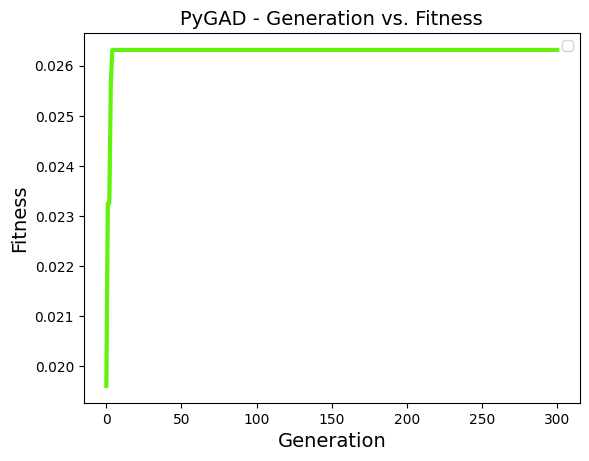

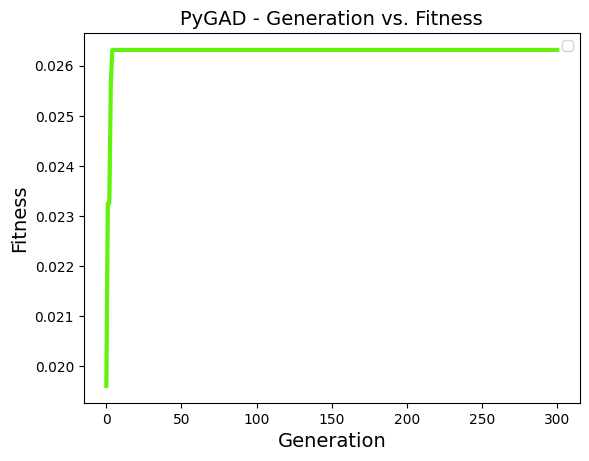

In [3]:
import numpy as np
import pygad
import random

# --- 1. CARGAR GRAFO (Igual que antes) ---
def load_graph(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    num_nodes = int(lines[0].strip())
    adj_matrix = np.full((num_nodes + 1, num_nodes + 1), np.inf)
    for line in lines[1:]:
        parts = list(map(int, line.strip().split()))
        if len(parts) == 3:
            u, v, w = parts
            adj_matrix[u][v] = w
            adj_matrix[v][u] = w # Comentar para dirigido
    return num_nodes, adj_matrix

# CONFIGURACIÓN INICIAL
filename = 'graph_medium.txt' # Asegúrate de tener este archivo creado de la tarea anterior
num_nodes, adj_matrix = load_graph(filename)

# --- 2. DEFINICIÓN DE OBJETIVOS ---
# Queremos ir de 1 -> 5 -> 10 (Por ejemplo)
# Puedes añadir más: [1, 2, 5, 8, 10]
TARGETS = [1, 5, 10] 
NUM_SEGMENTS = len(TARGETS) - 1
GENES_PER_SEGMENT = 10 # Longitud máxima para ir de un punto a otro (ajustar según tamaño grafo)
TOTAL_GENES = NUM_SEGMENTS * GENES_PER_SEGMENT

print(f"Ruta Objetivo: {TARGETS}")
print(f"Estructura del Cromosoma: {NUM_SEGMENTS} segmentos de {GENES_PER_SEGMENT} genes.")

# --- 3. POBLACIÓN INICIAL PERSONALIZADA ---
# El enunciado pide: "implement constraints into the starting population"
# Creamos caminos aleatorios pero que respetan el inicio de cada segmento.
def create_population():
    population = []
    for _ in range(50): # Tamaño población 50
        individual = []
        for i in range(NUM_SEGMENTS):
            # Para el segmento i, intentamos hacer un camino aleatorio desde TARGETS[i]
            # (Aunque PyGAD luego sobreescribirá con números random, esto ayuda si usamos custom init más complejo)
            # Para simplificar con PyGAD standard, usaremos su init aleatorio y confiaremos en la fitness,
            # pero la estructura lógica la mantenemos.
            pass 
        # PyGAD generará enteros aleatorios, nosotros los interpretaremos en la fitness.
    return None # Dejamos que PyGAD cree la matriz aleatoria inicial por simplicidad

# --- 4. FITNESS FUNCTION (La Clave) ---
def fitness_multi_target(ga_instance, solution, solution_idx):
    total_dist = 0
    
    # Recorremos cada segmento de la misión
    for i in range(NUM_SEGMENTS):
        start_node_target = TARGETS[i]
        end_node_target = TARGETS[i+1]
        
        # Extraer la parte del cromosoma que corresponde a este tramo
        start_idx = i * GENES_PER_SEGMENT
        end_idx = start_idx + GENES_PER_SEGMENT
        segment_genes = solution[start_idx:end_idx]
        
        # Evaluar este tramo (igual que en Task 1)
        current_node = start_node_target
        dist_segment = 0
        found = False
        visited_in_segment = {current_node} # Evitar ciclos locales
        
        for gene in segment_genes:
            next_node = int(gene)
            if next_node == current_node: continue
            
            # Distancia
            d = adj_matrix[current_node][next_node]
            
            if d == np.inf:
                dist_segment += 500 # Penalización por muro (suave para permitir cruce)
            else:
                dist_segment += d
                current_node = next_node
                
            if current_node == end_node_target:
                found = True
                break # Terminar este segmento, ¡éxito!
                
        if found:
            total_dist += dist_segment
        else:
            # Penalización MUY fuerte si no conecta el segmento A -> B
            # Esto fuerza al algoritmo a priorizar la conectividad antes que la distancia
            total_dist += 10000 

    if total_dist == 0: return 99999
    return 1.0 / total_dist

# --- 5. CUSTOM CROSSOVER (Cruce Personalizado) ---
# El enunciado pide: "implement constraints into crossover"
# Estrategia: Cruzar SEGMENTOS enteros.
# Si Padre 1 es bueno en A->B y Padre 2 es bueno en B->C, el hijo debe tener ambas partes buenas.
def custom_crossover_segments(parents, offspring_size, ga_instance):
    offspring = []
    idx = 0
    while len(offspring) < offspring_size[0]:
        parent1 = parents[idx % len(parents)]
        parent2 = parents[(idx + 1) % len(parents)]
        
        child = []
        # Para cada segmento de la ruta (ej. A->B, B->C)
        for i in range(NUM_SEGMENTS):
            start = i * GENES_PER_SEGMENT
            end = start + GENES_PER_SEGMENT
            
            # 50% de probabilidad de heredar el tramo de mamá o de papá
            if random.random() < 0.5:
                child.extend(parent1[start:end])
            else:
                child.extend(parent2[start:end])
        
        offspring.append(np.array(child))
        idx += 1
    return np.array(offspring)

# --- 6. CUSTOM MUTATION (Mutación Personalizada) ---
# El enunciado pide: "custom mutation"
def custom_mutation_segments(offspring, ga_instance):
    # Recorremos cada individuo
    for idx in range(len(offspring)):
        # Mutamos un porcentaje de genes
        for gene_idx in range(len(offspring[idx])):
            if random.random() < 0.1: # 10% chance de mutar un gen
                # Asignamos un nuevo nodo aleatorio del grafo
                new_gene = random.randint(1, num_nodes)
                offspring[idx][gene_idx] = new_gene
    return offspring

# --- 7. EJECUCIÓN ---
gene_space = list(range(1, num_nodes + 1))

ga_instance = pygad.GA(
    num_generations=300,    # Necesitamos más generaciones
    num_parents_mating=10,
    fitness_func=fitness_multi_target,
    sol_per_pop=100,        # Población más grande ayuda
    num_genes=TOTAL_GENES,
    gene_type=int,
    gene_space=gene_space,
    parent_selection_type="rws",
    
    # USAMOS NUESTRAS FUNCIONES PERSONALIZADAS
    crossover_type=custom_crossover_segments,
    mutation_type=custom_mutation_segments,
    
    keep_parents=2
)

print("Entrenando para ruta multi-objetivo...")
ga_instance.run()

# --- 8. RESULTADOS E INTERPRETACIÓN ---
solution, solution_fitness, _ = ga_instance.best_solution()

print(f"\nMejor Fitness: {solution_fitness}")
print("\n--- CAMINO DETALLADO ---")

full_path_nodes = []
valid_total = True

for i in range(NUM_SEGMENTS):
    start_target = TARGETS[i]
    end_target = TARGETS[i+1]
    
    # Extraer genes del segmento
    idx_start = i * GENES_PER_SEGMENT
    segment = solution[idx_start : idx_start + GENES_PER_SEGMENT]
    
    # Reconstruir camino
    curr = start_target
    path_segment = [curr]
    dist_segment = 0
    found = False
    
    for node in segment:
        node = int(node)
        if node == curr: continue
        d = adj_matrix[curr][node]
        
        if d != np.inf:
            dist_segment += d
            curr = node
            path_segment.append(curr)
            if curr == end_target:
                found = True
                break
    
    print(f"Tramo {start_target} -> {end_target}: {'OK' if found else 'FALLO'}")
    print(f"  Ruta: {path_segment} (Costo: {dist_segment})")
    
    if not found: valid_total = False
    # Añadir al path global (evitando duplicar el nodo de unión)
    if i == 0:
        full_path_nodes.extend(path_segment)
    else:
        full_path_nodes.extend(path_segment[1:])

if valid_total:
    print(f"\n¡ÉXITO! Ruta Completa Válida: {full_path_nodes}")
else:
    print("\nEl algoritmo no logró conectar todos los puntos. Intenta más generaciones.")

# Gráfico
ga_instance.plot_fitness()

In [4]:
import pygad
import numpy as np
import random
import math

# --- 1. FUNCIÓN PARA CARGAR EL GRAFO (from Seminar1.ipynb) ---

def load_graph(filename):
    """Carga el grafo desde un archivo de texto y construye una matriz de adyacencia."""
    try:
        with open(filename, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Error: File {filename} not found.")
        return 0, np.array([[]])

    num_nodes = int(lines[0].strip())
    # Initialize adjacency matrix with infinity (no connection)
    adj_matrix = np.full((num_nodes + 1, num_nodes + 1), np.inf)
    # Distance from node to itself is 0, but for simulation,
    # we rely on adj_matrix[C][D] == np.inf to detect invalid moves.
    # We will fill diagonal with 0 *after* setup for clarity.

    for line in lines[1:]:
        if not line.strip(): continue
        try:
            u, v, w = map(int, line.strip().split())
            adj_matrix[u][v] = w
            adj_matrix[v][u] = w
        except ValueError:
            continue

    np.fill_diagonal(adj_matrix, 0) # Set self-distance to 0

    return num_nodes, adj_matrix

# --- 2. CONFIGURACIÓN DEL PROBLEMA (Task 3 Parameters) ---

# --- Parámetros de simulación ---

FILENAME = 'graph_large.txt'
NUM_AGENTS = 2                  # Probar con 3, 5, 10
START_NODES = [1, 3]            # S1, S2, ... Sm
TARGET_SEQUENCE = [2, 4, 5, 8]  # A, B, C, ... N
MAX_STEPS_PER_AGENT = 30        # Max actions per agent (L)

# --- Constantes de tiempo ---
MOVE_POST_WAIT_TIME = 10 # Tiempo de espera después de un movimiento (d + 10)
WAIT_ACTION_TIME = 20    # Tiempo de una acción "wait" (quedarse en el nodo)

# --- Cargar Grafo ---
num_nodes, adj_matrix = load_graph(FILENAME)

if num_nodes > 0:
    # --- Parámetros del GA ---
    GENE_SPACE = list(range(1, num_nodes + 1))
    NUM_GENES = NUM_AGENTS * MAX_STEPS_PER_AGENT

    # --- Parámetros de GA (Ajustados de nuestras pruebas) ---
    NUM_GENERATIONS = 1000          # Probar con 500, 2000
    SOL_PER_POP = 200               # Probar con 50, 400
    MUTATION_PROBABILITY = 0.25     # Probar con 0.5

    # --- Penalización (Ajustada de nuestras pruebas) ---
    INVALID_MOVE_PENALTY = 1000000 # Penalización muy alta
    TARGET_MISS_PENALTY = 100000   # Penalización por no alcanzar todos los objetivos
else:
    print("Error al cargar el grafo. El script no se ejecutará.")

# --- 3. HELPER FUNCTIONS & FITNESS FUNCTION ---

def path_segments_to_paths(solution, num_agents, max_steps):
    """Divide el cromosoma plano en una lista de listas (un path por agente)."""
    paths = []
    for i in range(num_agents):
        start = i * max_steps
        end = (i + 1) * max_steps
        paths.append(list(solution[start:end]))
    return paths

def get_node_release_time(time_tracker, node):
    """Devuelve la hora a la que el nodo 'node' queda libre."""
    return time_tracker.get(node, 0)

def set_node_release_time(time_tracker, node, release_time):
    """Establece la hora a la que el nodo 'node' queda libre."""
    time_tracker[node] = release_time

def get_edge_release_time(time_tracker, u, v):
    """Devuelve la hora a la que la arista (u, v) queda libre."""
    edge = tuple(sorted((u, v))) # Clave canónica para aristas bidireccionales
    return time_tracker.get(edge, 0)

def set_edge_release_time(time_tracker, u, v, release_time):
    """Establece la hora a la que la arista (u, v) queda libre."""
    edge = tuple(sorted((u, v)))
    time_tracker[edge] = release_time


def fitness_function_task3(ga_instance, solution, solution_idx):
    """
    Función de fitness para Tarea 3.
    Simula el movimiento de N agentes con detección de colisiones.
    """

    # --- Inicialización de la Simulación ---
    node_release_time = {} # Dict {node: release_time}
    edge_release_time = {} # Dict {(u,v): release_time}

    agent_state = []
    for i, start_node in enumerate(START_NODES):
        agent_state.append({
            'id': i,
            'current_node': start_node,
            'target_idx': 0,          # Qué objetivo de TARGET_SEQUENCE está buscando
            'next_action_time': 0,    # Hora a la que el agente está listo para su próxima acción
            'step_idx': 0,            # Índice de la acción actual en su cromosoma
            'is_finished': False,     # ¿Ha terminado todas sus acciones o ha fallado?
            'penalty': 0
        })
        # El nodo de inicio está ocupado por el agente en t=0
        set_node_release_time(node_release_time, start_node, 0)

    # Extraer los paths del cromosoma
    agent_paths = path_segments_to_paths(solution, NUM_AGENTS, MAX_STEPS_PER_AGENT)

    total_targets_to_hit = len(TARGET_SEQUENCE) * NUM_AGENTS
    targets_hit_count = 0

    # --- Bucle de Simulación ---
    # Simular hasta que todos los agentes terminen

    simulation_steps = 0
    max_sim_steps = NUM_AGENTS * MAX_STEPS_PER_AGENT * 2 # Evitar bucles infinitos

    while simulation_steps < max_sim_steps:

        # 1. Comprobar si todos los agentes han terminado
        if all(a['is_finished'] for a in agent_state):
            break

        # 2. Encontrar el siguiente agente listo para actuar
        ready_agents = [a for a in agent_state if not a['is_finished']]
        if not ready_agents:
            break # Todos terminaron

        ready_agents.sort(key=lambda x: x['next_action_time'])
        agent = ready_agents[0] # El agente que actúa primero

        # 3. Obtener la acción del agente
        C = agent['current_node'] # Nodo actual

        # Comprobar si el agente ha agotado sus pasos
        if agent['step_idx'] >= MAX_STEPS_PER_AGENT:
            agent['is_finished'] = True
            continue

        D = agent_paths[agent['id']][agent['step_idx']] # Nodo de destino (siguiente gen)
        agent['step_idx'] += 1

        t_ready = agent['next_action_time'] # Hora a la que el agente está listo

        # --- 4. Procesar la Acción ---

        # --- ACCIÓN: ESPERAR (WAIT) ---
        if D == C:
            t_action = WAIT_ACTION_TIME # 20 unidades

            # El agente debe esperar a que el nodo C esté libre
            t_node_free = get_node_release_time(node_release_time, C)

            # La acción comienza cuando el agente está listo Y el nodo está libre
            t_start = max(t_ready, t_node_free)
            t_release = t_start + t_action

            # Actualizar estado
            agent['next_action_time'] = t_release
            set_node_release_time(node_release_time, C, t_release) # El nodo C está ocupado

        # --- ACCIÓN: MOVER (MOVE) ---
        else:
            d = adj_matrix[C][D]

            # 4a. Comprobar si es un movimiento VÁLIDO
            if d == np.inf:
                agent['penalty'] += INVALID_MOVE_PENALTY # Penalización masiva
                agent['is_finished'] = True # Este agente no puede continuar
                continue

            t_move = d # Tiempo de viaje
            t_post_wait = MOVE_POST_WAIT_TIME # 10 unidades

            # 4b. Comprobar disponibilidad de recursos (Colisiones)

            # Cuándo está libre la arista (C, D)?
            t_edge_free = get_edge_release_time(edge_release_time, C, D)
            # Cuándo está libre el nodo destino D?
            t_node_free = get_node_release_time(node_release_time, D)

            # El agente debe iniciar el movimiento (t_start) de forma que:
            # 1. Esté listo: t_start >= t_ready
            # 2. La arista esté libre: t_start >= t_edge_free
            # 3. Llegue a D (t_arrival) *después* de que D esté libre:
            #    t_arrival = t_start + t_move
            #    t_arrival >= t_node_free  =>  t_start + t_move >= t_node_free
            #    => t_start >= t_node_free - t_move

            t_start = max(t_ready, t_edge_free, t_node_free - t_move)

            t_arrival = t_start + t_move
            t_release = t_arrival + t_post_wait # El nodo D está ocupado hasta este momento

            # 4c. Actualizar estado y recursos
            agent['current_node'] = D
            agent['next_action_time'] = t_release

            set_edge_release_time(edge_release_time, C, D, t_arrival) # Arista libre al llegar
            set_node_release_time(node_release_time, D, t_release) # Nodo libre tras la espera

            # 4d. Comprobar si se alcanzó un objetivo
            if agent['target_idx'] < len(TARGET_SEQUENCE):
                current_target = TARGET_SEQUENCE[agent['target_idx']]
                if D == current_target:
                    agent['target_idx'] += 1 # Objetivo alcanzado, buscar el siguiente
                    targets_hit_count += 1

        simulation_steps += 1

    # --- 5. Cálculo Final del Fitness ---

    # El tiempo total es el momento en que el *último* agente termina su *última* acción
    final_time = max(a['next_action_time'] for a in agent_state)

    total_penalty = sum(a['penalty'] for a in agent_state)

    # Penalización por objetivos no alcanzados
    targets_missed = total_targets_to_hit - targets_hit_count
    total_penalty += (targets_missed * TARGET_MISS_PENALTY)

    # El fitness es inverso al tiempo total + penalizaciones
    # Añadimos 1.0 para evitar la división por cero
    fitness = 1.0 / (final_time + total_penalty + 1.0)

    return fitness

# --- 4. CUSTOM MUTATION OPERATOR ---

def custom_mutation(offspring, ga_instance):
    """
    Mutación personalizada que respeta la conectividad del grafo.
    Un gen solo puede mutar a:
    1. Un nodo vecino del gen *anterior*.
    2. El mismo nodo que el gen *anterior* (una acción de ESPERA).
    """
    for chromosome_idx in range(offspring.shape[0]):
        # Iterar sobre cada gen en el cromosoma
        for gene_idx in range(offspring.shape[1]):

            # Aplicar mutación según la probabilidad
            if random.random() < ga_instance.mutation_probability:

                # Identificar a qué agente y paso pertenece este gen
                agent_id = gene_idx // MAX_STEPS_PER_AGENT
                step_idx = gene_idx % MAX_STEPS_PER_AGENT

                # Encontrar el nodo anterior (C)
                if step_idx == 0:
                    # Si es el primer paso, el nodo anterior es el nodo inicial
                    C = START_NODES[agent_id]
                else:
                    # El nodo anterior es el gen previo de este agente
                    prev_gene_idx = gene_idx - 1
                    C = offspring[chromosome_idx, prev_gene_idx]

                # Construir la lista de movimientos válidos (vecinos + C)
                valid_next_nodes = [C] # La acción de ESPERA (C -> C) siempre es válida

                # Buscar vecinos en la matriz de adyacencia
                for D in range(1, num_nodes + 1):
                    if D != C and adj_matrix[C][D] != np.inf:
                        valid_next_nodes.append(D)

                # Asignar un nuevo valor de gen aleatorio de la lista válida
                offspring[chromosome_idx, gene_idx] = random.choice(valid_next_nodes)

    return offspring

# --- 5. GA INITIALIZATION AND EXECUTION ---

def run_ga_task3():

    if num_nodes == 0:
        print("El grafo no se cargó. Abortando la ejecución del GA.")
        return

    # Wrapper de fitness para manejar la firma requerida por pygad (3 argumentos)
    def fitness_wrapper(ga_instance, solution, solution_idx):
        return fitness_function_task3(
            ga_instance,
            solution,
            solution_idx
        )

    ga_instance = pygad.GA(
        num_generations=NUM_GENERATIONS,
        num_parents_mating=10,
        fitness_func=fitness_wrapper,
        sol_per_pop=SOL_PER_POP,
        num_genes=NUM_GENES,
        gene_type=int,
        gene_space=GENE_SPACE,

        # --- Operadores Genéticos ---
        crossover_type="single_point", # Como se pide, experimentar con crossover
        mutation_type=custom_mutation, # Mutación personalizada OBLIGATORIA
        mutation_probability=MUTATION_PROBABILITY,

        parent_selection_type="rws",  # Roulette wheel selection
        save_best_solutions=False,    # Ahorrar memoria (evitar UserWarning)
        keep_elitism=2                # Mantener a los 2 mejores individuos
    )

    print(f"Buscando solución para {NUM_AGENTS} agentes (starts: {START_NODES}) cubriendo targets: {TARGET_SEQUENCE}")
    print(f"Usando grafo: {FILENAME}")
    print(f"Cromosoma length: {NUM_GENES} (Max steps: {MAX_STEPS_PER_AGENT})")
    print("\n--- Running GA ---")

    ga_instance.run()

    # --- 6. Display Best Solution ---
    solution, solution_fitness, solution_idx = ga_instance.best_solution()

    # Calcular el tiempo total (inverso del fitness)
    # (Restamos 1.0 que añadimos para evitar división por cero)
    total_cost = (1.0 / solution_fitness) - 1.0

    print(f"\n--- GA Finished ---")
    print(f"Mejor Fitness: {solution_fitness}")
    print(f"Mejor Costo (Tiempo Total + Penalizaciones): {total_cost:.2f}")

    best_paths = path_segments_to_paths(solution, NUM_AGENTS, MAX_STEPS_PER_AGENT)

    print("\nBest Agent Paths (Node-by-Node Action Sequence):")

    # Imprimir un path "limpio" que muestre 'wait'
    for i, path_segment in enumerate(best_paths):
        effective_path = []
        current_node = START_NODES[i]

        targets_hit_by_agent = 0

        for next_node in path_segment:
            if next_node == current_node:
                effective_path.append(f'wait@{current_node}')
            elif adj_matrix[current_node][next_node] != np.inf:
                effective_path.append(next_node)

                # Comprobar si este movimiento alcanzó un objetivo
                if targets_hit_by_agent < len(TARGET_SEQUENCE):
                    if next_node == TARGET_SEQUENCE[targets_hit_by_agent]:
                        targets_hit_by_agent += 1

                current_node = next_node
            else:
                # Este 'INVALID_MOVE' no debería ocurrir si la mutación
                # y la penalización funcionan, pero es una buena comprobación.
                effective_path.append(f'INVALID_MOVE_TO_{next_node}')
                break

        print(f"Agent {i+1} (Start: {START_NODES[i]}): [{START_NODES[i]}, {' , '.join(map(str, effective_path))}]")
        print(f"  (Targets alcanzados por este agente: {targets_hit_by_agent}/{len(TARGET_SEQUENCE)})")

    # Descomentar para mostrar el gráfico de fitness si se ejecuta en un entorno que lo soporte
    # ga_instance.plot_fitness()

# --- Ejecutar el GA ---
# Asegúrate de tener el archivo 'graph_large.txt' en el mismo directorio
run_ga_task3()

Buscando solución para 2 agentes (starts: [1, 3]) cubriendo targets: [2, 4, 5, 8]
Usando grafo: graph_large.txt
Cromosoma length: 60 (Max steps: 30)

--- Running GA ---

--- GA Finished ---
Mejor Fitness: 7.68914331409766e-07
Mejor Costo (Tiempo Total + Penalizaciones): 1300534.00

Best Agent Paths (Node-by-Node Action Sequence):
Agent 1 (Start: 1): [1, 17 , 1 , 2 , 11 , 20 , 3 , INVALID_MOVE_TO_15]
  (Targets alcanzados por este agente: 1/4)
Agent 2 (Start: 3): [3, 20 , 3 , 19 , 3 , 2 , 3 , 4 , 5 , 6 , 7 , 2 , 14 , 5 , 14 , 13 , wait@13 , 14 , 4 , 3 , 2 , wait@2 , 7 , 8 , 3 , 20 , wait@20 , 3 , 1 , 20 , 11]
  (Targets alcanzados por este agente: 4/4)
